# BPNet benchmark performance vs read depth

Generates atlas-wide read-depth benchmark plots for BPNet models. Points are experiments, colored by model warning flag and annotated with the read-depth thresholds used by `configs/model_warning_flags.tsv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PLOTS_DIR = REPO_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)
FIGURE_SIZE_PT = 128.3
FIGURE_SIZE_IN = FIGURE_SIZE_PT / 72

METRICS_PATH = REPO_ROOT / "performance_metrics" / "bpnet" / "procap-atlas_performance_metrics.tsv"
FLAGS_PATH = REPO_ROOT / "configs" / "model_warning_flags.tsv"
READ_THRESHOLDS = {
    "red": 10_000_000,
    "yellow": 20_000_000,
}
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "axes.linewidth": 0.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
})
FLAG_COLORS = {
    "green": "#2b6cb0",
    "yellow": "#f0b400",
    "red": "#d7301f",
}
SPECIAL_MARKER_COLOR = "0.35"
PROBLEM_TSS_EXPERIMENTS = {"ENCSR973QQI": "ReNcell CX"}


In [6]:
metrics["profile_jsd"] ** (1/2)

0      0.673980
1      0.673820
2      0.542712
3      0.578694
4      0.559762
         ...   
219    0.583764
220    0.569515
221    0.571086
222    0.577472
223    0.562552
Name: profile_jsd, Length: 224, dtype: float64

## Load benchmark metrics and flags

In [7]:
metrics = pd.read_csv(METRICS_PATH, sep="	")
metrics["profile_jsd"] = metrics["profile_jsd"] ** (1/2)
flags = pd.read_csv(FLAGS_PATH, sep="	")

flag_cols = [
    "experiment",
    "overall_flag",
    "read_flag",
    "is_perturbation",
    "is_uncapped",
    "flags",
]
plot_df = metrics.merge(flags[flag_cols], on="experiment", how="left")
plot_df["overall_flag"] = pd.Categorical(
    plot_df["overall_flag"].fillna("green"),
    categories=["green", "yellow", "red"],
    ordered=True,
)
plot_df["read_depth_millions"] = plot_df["total_reads"] / 1e6
plot_df["log10_total_reads"] = np.log10(plot_df["total_reads"])


summary = {
    "n_experiments": len(plot_df),
    "n_biosamples": plot_df["biosample"].nunique(),
    "median_reads_millions": plot_df["read_depth_millions"].median(),
    "median_log_counts_pearson": plot_df["log_counts_pearson"].median(),
    "median_profile_jsd": plot_df["profile_jsd"].median(),
}
summary


{'n_experiments': 224,
 'n_biosamples': 126,
 'median_reads_millions': 29.338451,
 'median_log_counts_pearson': 0.6963573821953364,
 'median_profile_jsd': 0.5976264326991534}

## Plot helpers

In [8]:
def _format_read_depth_axis(ax):
    ax.set_xscale("log")
    ax.set_xlim(1.5e5, 1.5e8)
    ax.set_xticks([1e6, 1e7, 2e7, 5e7, 1e8])
    ax.set_xticklabels(["1", "10", "20", "50", "100"])
    ax.set_xlabel("Total PRO-cap reads (millions)")


def _annotate_thresholds(ax):
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    for label, value in READ_THRESHOLDS.items():
        color = FLAG_COLORS[label]
        ax.axvline(value, color=color, linestyle="--", linewidth=1.0, alpha=0.9)
        xoffset = -4 if label == "red" else 4
        ha = "right" if label == "red" else "left"
        ax.annotate(
            f"{value / 1e6:.0f}M",
            xy=(value, ymin + 0.04 * yrange),
            xytext=(xoffset, 0),
            textcoords="offset points",
            color=color,
            fontsize=7,
            va="bottom",
            ha=ha,
        )
    ax.set_ylim(ymin, ymax)


def _add_flag_legend(ax):
    flag_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            label=f"{flag} (n={(plot_df['overall_flag'] == flag).sum()})",
            markerfacecolor=FLAG_COLORS[flag],
            markeredgecolor="white",
            markeredgewidth=0.5,
            markersize=6,
        )
        for flag in ["green", "yellow", "red"]
    ]
    extra_handles = [
        Line2D([0], [0], marker="^", color=SPECIAL_MARKER_COLOR, label="perturbation", linestyle="none", markersize=6),
        Line2D([0], [0], marker="s", color=SPECIAL_MARKER_COLOR, label="uncapped", linestyle="none", markersize=6),
        Line2D([0], [0], marker="X", color=SPECIAL_MARKER_COLOR, label="problematic TSS positioning", linestyle="none", markersize=6),
    ]
    ax.legend(
        handles=flag_handles + extra_handles,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
    )


def plot_metric_vs_read_depth(
    ax,
    metric,
    ylabel,
    better,
    ylim=None,
    legend=False,
):
    regular = ~(plot_df["is_perturbation"].fillna(False) | plot_df["is_uncapped"].fillna(False))
    ax.scatter(
        plot_df.loc[regular, "total_reads"],
        plot_df.loc[regular, metric],
        c=plot_df.loc[regular, "overall_flag"].map(FLAG_COLORS),
        marker="o",
        s=24,
        alpha=0.78,
        linewidth=0.35,
        edgecolor="white",
    )

    marker_specs = [
        ("is_perturbation", "^", 34),
        ("is_uncapped", "s", 32),
    ]
    for flag_col, marker, size in marker_specs:
        rows = plot_df[plot_df[flag_col].fillna(False)]
        ax.scatter(
            rows["total_reads"],
            rows[metric],
            c=SPECIAL_MARKER_COLOR,
            marker=marker,
            s=size,
            alpha=0.88,
            linewidth=0,
            zorder=4,
        )

    tss_rows = plot_df[plot_df["experiment"].isin(PROBLEM_TSS_EXPERIMENTS)]
    ax.scatter(
        tss_rows["total_reads"],
        tss_rows[metric],
        c=SPECIAL_MARKER_COLOR,
        marker="X",
        s=58,
        alpha=0.95,
        linewidth=0.35,
        edgecolor="white",
        zorder=5,
    )

    _format_read_depth_axis(ax)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    _annotate_thresholds(ax)

    pearson = pearsonr(plot_df["log10_total_reads"], plot_df[metric])
    spearman = spearmanr(plot_df["total_reads"], plot_df[metric])
    direction = "higher is better" if better == "higher" else "lower is better"
    ax.text(
        0.02,
        0.98,
        f"N={len(plot_df)} experiments\nPearson r={pearson.statistic:.2f}\nSpearman rho={spearman.statistic:.2f}\n{direction}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=7,
        bbox={"boxstyle": "round,pad=0.22", "facecolor": "white", "edgecolor": "0.85", "alpha": 0.88},
    )
    if legend:
        _add_flag_legend(ax)


## Square single-panel figures

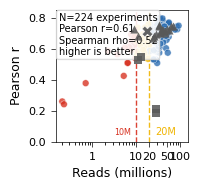

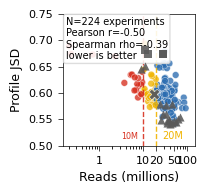

In [ ]:
single_panel_specs = [
    ("log_counts_pearson", "Pearson r", "higher", (0.0, 0.85), "bpnet_log_counts_pearson_vs_read_depth_annotated"),
    ("profile_jsd", "Profile JSD", "lower", (0.5, 0.75), "bpnet_profile_jsd_vs_read_depth_annotated"),
]

for metric, ylabel, better, ylim, stem in single_panel_specs:
    fig, ax = plt.subplots(figsize=(FIGURE_SIZE_IN, FIGURE_SIZE_IN))
    plot_metric_vs_read_depth(ax, metric, ylabel, better, ylim=ylim, legend=False)
    ax.set_xlabel("Reads (millions)")
    ax.set_ylabel(ylabel)
    ax.set_box_aspect(1)
    ax.texts[0].set_fontsize(5.8)
    fig.subplots_adjust(left=0.22, right=0.96, bottom=0.20, top=0.96)
    fig.savefig(PLOTS_DIR / f"{stem}.pdf", dpi=300)
    #fig.savefig(PLOTS_DIR / f"{stem}.png", dpi=300)
    plt.show()


## Read-depth bins

In [11]:
read_bins = pd.cut(
    plot_df["total_reads"],
    bins=[0, 10_000_000, 20_000_000, 50_000_000, np.inf],
    labels=["<10M", "10-20M", "20-50M", ">50M"],
)
plot_df.groupby(read_bins, observed=True).agg(
    experiments=("experiment", "count"),
    median_log_counts_pearson=("log_counts_pearson", "median"),
    median_profile_jsd=("profile_jsd", "median"),
    median_total_reads=("total_reads", "median"),
)


,experiments,median_log_counts_pearson,median_profile_jsd,median_total_reads
total_reads,,,,
<10M,21,0.605032,0.620072,7310110.0
10-20M,38,0.650782,0.599257,15223984.0
20-50M,146,0.704362,0.596573,30829160.5
>50M,19,0.722388,0.581803,54754455.0
